x_R, y_R, x_I, y_I = (202, 109, 62, 62)
index 203 is out of bounds for axis 0 with size 203
x_R, y_R, x_I, y_I = (202, 110, 63, 63)
index 203 is out of bounds for axis 0 with size 203
x_R, y_R, x_I, y_I = (202, 111, 64, 64)
index 203 is out of bounds for axis 0 with size 203
x_R, y_R, x_I, y_I = (202, 112, 65, 66)
index 203 is out of bounds for axis 0 with size 203
x_R, y_R, x_I, y_I = (202, 103, 56, 56)
index 203 is out of bounds for axis 0 with size 203
x_R, y_R, x_I, y_I = (202, 104, 57, 57)
index 203 is out of bounds for axis 0 with size 203
x_R, y_R, x_I, y_I = (202, 105, 58, 58)
index 203 is out of bounds for axis 0 with size 203
x_R, y_R, x_I, y_I = (202, 106, 59, 59)
index 203 is out of bounds for axis 0 with size 203
x_R, y_R, x_I, y_I = (202, 107, 60, 60)
index 203 is out of bounds for axis 0 with size 203
x_R, y_R, x_I, y_I = (202, 108, 61, 61)
index 203 is out of bounds for axis 0 with size 203
x_R, y_R, x_I, y_I = (202, 98, 50, 50)
index 203 is out of bounds for axis 0 wit

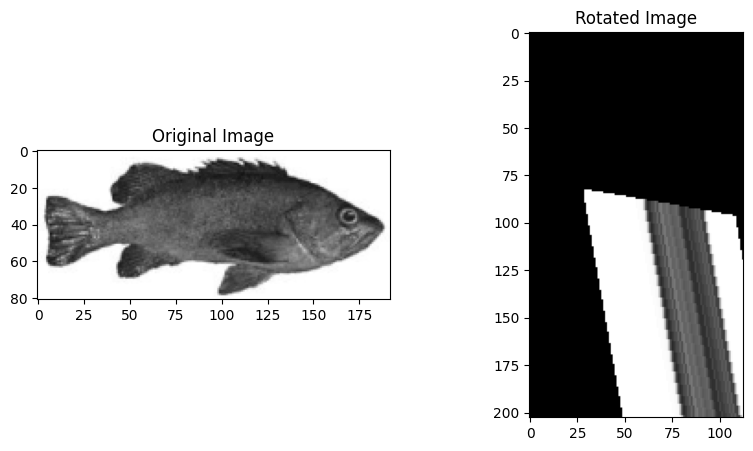

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from PIL import Image

def rotate_column_major(I, theta, m, n, m_prime, n_prime):
    R = np.zeros((m_prime, n_prime), dtype=I.dtype)

    sx = m * abs(math.sin(theta))
    sy = n * abs(math.cos(theta))

    delta_x = abs(math.sin(theta))
    delta_y = abs(math.cos(theta))

    # Calculate η for checking negativity
    eta = (
        1 if theta in [math.pi, 5 * math.pi / 4, (3 * math.pi) / 2, 2 * math.pi] else 0
    )

    delta_i = ((-1) ** eta) / delta_x

    r_o = math.ceil(n * abs(math.sin(theta)))
    r_i = m

    # Perform the rotation
    for i in range(r_o):
        i_prime = 0

        f_i = math.floor(i / abs(math.tan(theta)))

        x_prime = f_i
        y_prime = i

        for p in range(r_i):
            if theta in [5 * math.pi / 4, 7 * math.pi / 4]:
                j = r_i - p - 1
            else:
                j = p

            x_I, y_I = j, math.floor(i_prime)

            x_R = int((-1) ** eta * math.floor((y_prime + sy)))
            y_R = int((-1) ** eta * math.floor((x_prime + sx)))

            # Map the pixels
            if 0 <= x_R < m_prime and 0 <= y_R < n_prime:
                try:
                    R[x_R, y_R] = I[x_I, y_I]
                    R[x_R + 1, y_R] = I[x_I, y_I]
                except Exception as e:
                    print(f"{x_R, y_R, x_I, y_I = }")
                    print(e)

            x_prime += delta_x
            y_prime += delta_y

            i_prime += delta_i

    return R


input_image_path = "../assets/fish.png"  # Replace with your image file path
I = Image.open(input_image_path).convert("L")
I = np.array(I)

theta = math.radians(80)  # 45 degrees rotation

m, n = I.shape

m_prime, n_prime = round(abs(m * math.cos(theta)) + abs(n * math.sin(theta))), round(
    abs(n * math.cos(theta)) + abs(m * math.sin(theta))
)

R = rotate_column_major(I, theta, m, n, m_prime, n_prime)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(I, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Rotated Image")
plt.imshow(R, cmap="gray", vmin=0, vmax=255)
plt.show()